# Assignment Part 3

**Imports the library used for this part**

In [11]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import stopwords
import re
from collections import Counter
import openpyxl
import spacy
import pickle
import seaborn as sns
from scipy.sparse import vstack

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

#Import the Function used for data preprocessing in Part 1
import nbimporter
from IT2391_234707R_Part_1 import preprocess_part1,replace_month_abbrev,remove_encoded_text,preprocess_word,preprocess_text,preprocess_part2

# Import the SVM Model and TFIDF Vectorizer

In [12]:
with open('C:/Users/zhoul/Y2 Sem2/IT2391 NLP/IT2391_234707R_Assignment/Models/SVM-2024-12-13.pkl','rb') as f:
    model = pickle.load(f)

In [13]:
with open('C:/Users/zhoul/Y2 Sem2/IT2391 NLP/IT2391_234707R_Assignment/Models/TFIDF-2024-12-13.pkl','rb') as f:
    trained_tfidf = pickle.load(f)

# Pre-Processing of test data
I have applied all of the data cleaning step using in Part 1 in this part. I have done detailed explain about each function in part 1. But i will copy paste the explaination here too. <br>

These are the function that i have imported over from part 1 python file.<br>
preprocess_part1, replace_month_abbrev, remove_encoded_text, preprocess_word, preprocess_text, preprocess_part2
<br>

Function **preprocess_part1(df,column)** drop all missing values in the df[column], then drop all duplicates too.
Function **replace_month_abbrev(text)** Replace month abbreviation with full form.<br>
Function **remove_encoded_text(text)** clean text and handle encoding issues like �<br>
Function **preprocess_word(word)** preprocess text at word level, like removing stop words, removing months and filtering out words less than 3 character length<br>
Function **preprocess_text(text)** preprocess word, like removing stop words, removing months and lemmatizing words. <br>In this function, it will also be using other functions like *remove_encoded_text(text)*, *preprocess_word(word)*. Using Spacy English Core Sm for Lemmatization, word tokenizer and regex to filter out words too. <br>
Lastly, **preprocess_part2(df,column)**. This will use all of the above function to clean the data.

In [14]:
#Importing the test file here and making it a dataframe
pre_processing_df = pd.DataFrame(pd.read_excel('Data/Data_test.xlsx'))
pre_processing_df #Print out the Data Frame

,description,species
0,Looking for fun and interesting facts about a ...,Black-naped Oriole
1,Giant Panda. Grey Wolf. Canis lupus. Proboscis...,Black-naped Oriole
2,javanicus displayed during feeding such as wal...,Javan Myna
3,Black-naped Oriole: Explore more topics. Name;...,Black-naped Oriole
4,NaN,Javan Myna
5,"The Javan myna, also known as the white-vented...",Javan Myna
6,"Donâ€™t worry, itâ€™s not a typo error. It is ...",Javan Myna
7,The black-naped oriole (Oriolus chinensis) is ...,Black-naped Oriole
8,Oriolus chinensis is relatively medium in size...,Black-naped Oriole
9,Little Egret is a common waterbird in Hong Ko...,Little Egret


In [15]:
#Apply the preprocess_part 1 function here to remove empty value and missing value
pre_processing_df = preprocess_part1(pre_processing_df,'description')
pre_processing_df

,description,species
0,Looking for fun and interesting facts about a ...,Black-naped Oriole
1,Giant Panda. Grey Wolf. Canis lupus. Proboscis...,Black-naped Oriole
2,javanicus displayed during feeding such as wal...,Javan Myna
3,Black-naped Oriole: Explore more topics. Name;...,Black-naped Oriole
4,"The Javan myna, also known as the white-vented...",Javan Myna
5,"Donâ€™t worry, itâ€™s not a typo error. It is ...",Javan Myna
6,The black-naped oriole (Oriolus chinensis) is ...,Black-naped Oriole
7,Oriolus chinensis is relatively medium in size...,Black-naped Oriole
8,Little Egret is a common waterbird in Hong Ko...,Little Egret
9,LITTLE EGRET Egretta garzetta Ardeidae Family...,Little Egret


In [16]:
#Apply the preprocess_part 2 function here to clean the data. Detailed explaination above and in Part 1 file with function explaination
pre_processing_df = preprocess_part2(pre_processing_df,'description')
pre_processing_df

,species,processed_words
0,Black-naped Oriole,look fun interesting fact blacknape oriole lea...
1,Black-naped Oriole,giant panda grey wolf canis lupus proboscis mo...
2,Javan Myna,javanicu display feed walk jump hop glean run ...
3,Black-naped Oriole,blacknape oriole explore topic name descriptio...
4,Javan Myna,javan myna know whitevente myna specie myna me...
5,Javan Myna,worry typo error true common myna common sight...
6,Black-naped Oriole,blacknape oriole oriolus chinensis passerine b...
7,Black-naped Oriole,oriolus chinensis relatively medium size tip t...
8,Little Egret,little egret common waterbird hong kong since ...
9,Little Egret,little egret egretta garzetta ardeidae family ...


# This part will encode the text from the DataFrame to vector
**This part converts the encoded text to text. Which has multiple sparse matrices**

In [17]:
#This function below will Numerically encode the input, Convert the text to vectors using the imported Vectorizer
def encode_text_to_vector(tfidf,text):
    text_vector = tfidf.transform([text])#Transform the text into here
    return text_vector

#I will save all of the text vector into another list
new_text_vectors = []
for text in pre_processing_df['processed_words']: #Loop and encode text to vector
    text_vector = encode_text_to_vector(trained_tfidf, text) # use the function to encode text to vector
    new_text_vectors.append(text_vector) #Append it to the list, new text vectors

new_text_vectors #Print out the output of the encoded text vector

[<1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 27 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 21 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 10 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 18 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 37 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 17 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 46 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 62 stored elements in Compressed Sparse Row format>,
 <1x8940 sparse matrix of type '<class 'numpy.float64'>'
 	with 

**Combined all of the multiple sparse matrices into 1 sparse matrix**

In [18]:
# Stack / conatenate all sparse matrices into one sparse matrix using vstack
all_text_vectors = vstack(new_text_vectors)

# Make predictions for all texts at once to find out what species it is
predicted_labels = model.predict(all_text_vectors) #Predict using this code
predicted_prob = model.predict_proba(all_text_vectors)

pre_processing_df['prediction'] = predicted_labels #Made a new columns for prediction result
pre_processing_df['confidence'] = [f"{max(probs) * 100:.2f}%" for probs in predicted_prob] # Add the probabilty percentage here
pre_processing_df #Show data frame 

,species,processed_words,prediction,confidence
0,Black-naped Oriole,look fun interesting fact blacknape oriole lea...,Black-naped Oriole,59.83%
1,Black-naped Oriole,giant panda grey wolf canis lupus proboscis mo...,Black-naped Oriole,61.74%
2,Javan Myna,javanicu display feed walk jump hop glean run ...,Javan Myna,45.61%
3,Black-naped Oriole,blacknape oriole explore topic name descriptio...,Black-naped Oriole,99.92%
4,Javan Myna,javan myna know whitevente myna specie myna me...,Javan Myna,99.76%
5,Javan Myna,worry typo error true common myna common sight...,Javan Myna,99.99%
6,Black-naped Oriole,blacknape oriole oriolus chinensis passerine b...,Black-naped Oriole,99.95%
7,Black-naped Oriole,oriolus chinensis relatively medium size tip t...,Black-naped Oriole,98.23%
8,Little Egret,little egret common waterbird hong kong since ...,Little Egret,100.00%
9,Little Egret,little egret egretta garzetta ardeidae family ...,Little Egret,100.00%


# I will compare the prediction result against the original species 
You can see that out of 38 rows of data, the SVM model only predicted 1 wrongly.

In [19]:
#Find out the total row of data
total = len(pre_processing_df)

# Added a counter to find the amount of wrongly predicted
wrong_count = 0
#If prediction and actual species is not the same, add 1 to the wrong count
for pred, actual in zip(pre_processing_df['prediction'], pre_processing_df['species']):
    if pred != actual: 
        wrong_count += 1

print(f'Out of Total {total} rows of data. \nThe Total of wrong prediction was {wrong_count}')

Out of Total 38 rows of data. 
The Total of wrong prediction was 1


In [20]:
'''
This shows the wrongly predicted Dataframe rows
'''
wrongly_predicted_df = pre_processing_df[pre_processing_df['species'] != pre_processing_df['prediction']]
wrongly_predicted_df

,species,processed_words,prediction,confidence
29,Black-naped Oriole,provisional either member exotic population br...,Little Egret,70.95%


**This below will show the average 'Accuracy', 'Precision', 'Recall', 'F1-Score' for this model doing prediction with the test data**<br>
Overall, this model has an accuracy rate of 97.37%. Which predict 37/38 row correctly. Which indicate that this model is very accurate. <br>
Precision: When the model predicts the correct species, it is correct about 96.43% of the time.<br>
Recall: The model correctly identifies 98.44% of actual positive cases (species in this case).<br>
F1-Score: This model having 0.972705 (97.27%) indicates that this model has a good balance between precision and recall, indicating that this model has a strong overall performance, especially when considering both false positives and false negatives.

In [21]:
# Separate the labels species and prediction

y_true = pre_processing_df['species'] #Set variable of actual species
y_pred = pre_processing_df['prediction'] #Set variable of predicted species

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

performance_df = pd.DataFrame({
    'Value': [accuracy, precision, recall, f1]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T

performance_df

,Accuracy,Precision,Recall,F1-Score
Value,0.973684,0.964286,0.984375,0.972705


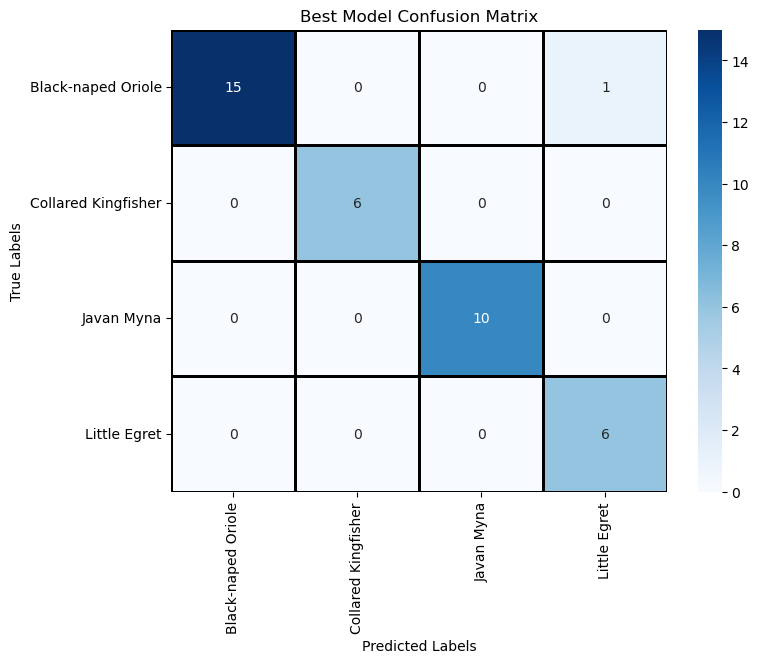

In [22]:
#Shows the confusion matrix
lr_cm = confusion_matrix(y_true,y_pred)
# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true), linewidths=1, linecolor='black')

# Labels and title
plt.title('Best Model Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

**This below will show the each of the species 'Precision', 'Recall', 'F1-Score' for this model doing prediction with the test data**

In [23]:
# Print out the precision, recall, f1-score and support for each species
print(classification_report(y_true, y_pred, target_names=np.unique(y_true)))

                     precision    recall  f1-score   support

 Black-naped Oriole       1.00      0.94      0.97        16
Collared Kingfisher       1.00      1.00      1.00         6
         Javan Myna       1.00      1.00      1.00        10
       Little Egret       0.86      1.00      0.92         6

           accuracy                           0.97        38
          macro avg       0.96      0.98      0.97        38
       weighted avg       0.98      0.97      0.97        38



# Looking at the Classification Report Above
**1. Precision**<br>
Black-naped Oriole: Perfect precision (1.00), every prediction of this species is correct.<br>
Collared Kingfisher: Perfect precision (1.00), every prediction of this species is correct.<br>
Javan Myna: Perfect precision (1.00), every prediction of this species is correct.<br>
Little Egret: Precision is 0.86, the lowest among the species, showing that the model is not so good in identifying this species correctly. Could use some more training data<br>
**2. Recall**<br>
Recall measures the percentage / proportion among all actual occurrences of a class.<br>
Collared Kingfisher,Javan Myna and Little Egret: Perfect recall (1.00), every actual instance of this species is correctly identified.<br>
But Black-naped Oriole: Recall is 0.94, this means that there is a few actual species that was not predicted correctly.<br>
**3. F1-Score**<br>
Black-naped Oriole: F1-score is 0.97, which is high with perfect precision but it has the lowest recall value <br>
Collared Kingfisher: Perfect F1-score (1.00), this indicate that it is execellent in both precision and recall.<br>
Javan Myna: Perfect F1-score (1.00), this indicate that it is execellent in both precision and recall.<br>
Little Egret: F1-score is 0.92, the worst among the species, showing that the model has a bad balance of both precision and recall.<br>
**4. Support**<br>
Black-naped Oriole: 16 instances<br>
Collared Kingfisher: 6 instances<br>
Javan Myna: 10 instances<br>
Little Egret: 6 instances<br>
This indicate that the class distribution between these 4 are imbalanced.

**Improvement**<br>
To improve the model to predict Little Egret is to either improve the data cleaning solution or have more data during train should help increase it precision<br>
To solve the data imbalance of each class. We can use oversampling methods like SMOTE to generate synthetic data to Collared Kingfisher and Little Egret to balanced it out with the rest. Which should improve the model improvement.<br>

